# Discrete State Space Model for Phasor Networks

Instead of solving a continuous ODE (`dz/dt = kz + I(t)`), we discretize the
Resonate-and-Fire neuron into a linear recurrence:

$$z[n+1] = A \cdot z[n] + B \cdot I[n]$$

where $A = \exp(k \cdot \Delta t)$, $B = (A-1)/k$, $k = \lambda + i\omega$.

Unrolling gives a **causal convolution**: $z[n] = \sum_j K[n-j] \cdot I[j]$, $K[n] = A^n \cdot B$,
computable in parallel via matrix multiply (small L) or FFT (large L).

This is the same insight behind **S4/S4D/Mamba**: diagonal complex state spaces
are equivalent to complex convolution kernels.

| Spiking system | SSM equivalent | Meaning |
|---|---|---|
| `spk_args.leakage` | `λ = -exp(log_neg_lambda)` | Decay rate (spiral inward speed) |
| `2π / spk_args.t_period` | `ω` (omega) | Angular frequency (rotation speed) |
| `solve(ODEProblem(...))` | `causal_conv(K, H)` | Temporal integration |
| `PhasorDense` weight | `ps.weight` | Channel mixing matrix |
| Per-channel `(λ, ω)` | SSM dynamics | Recurrence through leakage enables state |

The **SSMReadout** layer computes codebook similarity at every timestep before
averaging, avoiding phase-cancellation from averaging rotating phasors directly.

In [1]:
using PhasorNetworks
using Lux, Random, Optimisers, Zygote, Statistics
using MLDatasets, MLUtils, OneHotArrays
using CUDA, LuxCUDA
using Plots

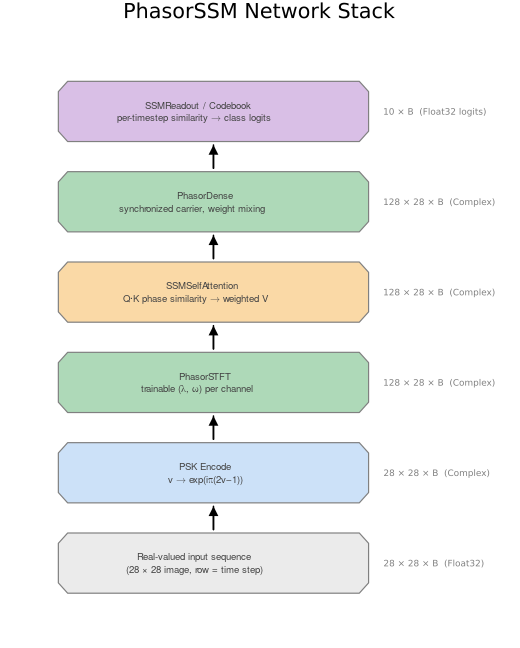

In [22]:
# ── Architecture diagram ──────────────────────────────────────────────
using Plots

function arch_diagram()
    # Layout constants
    box_w, box_h = 4.0, 0.7
    x_center = 0.0
    gap = 0.35                       # vertical gap between boxes
    arrow_len = gap                  # arrow spans the gap

    # Stack labels (bottom → top) and colours
    labels = [
        "Real-valued input sequence\n(28 × 28 image, row = time step)",
        "PSK Encode\nv → exp(iπ(2v−1))",
        "PhasorSTFT\ntrainable (λ, ω) per channel",
        "SSMSelfAttention\nQ·K phase similarity → weighted V",
        "PhasorDense\nsynchronized carrier, weight mixing",
        "SSMReadout / Codebook\nper-timestep similarity → class logits",
    ]
    fills = [
        RGB(0.92, 0.92, 0.92),   # input  – light gray
        RGB(0.80, 0.88, 0.97),   # encode – light blue
        RGB(0.68, 0.85, 0.72),   # STFT   – green
        RGB(0.98, 0.85, 0.65),   # attn   – orange
        RGB(0.68, 0.85, 0.72),   # dense  – green
        RGB(0.85, 0.75, 0.90),   # readout– purple
    ]
    n = length(labels)

    # y positions (bottom-up)
    y_bot = [(i - 1) * (box_h + gap) for i in 1:n]

    # Canvas
    total_h = y_bot[end] + box_h
    plt = plot(;
        xlims = (-2.6, 3.8),
        ylims = (-0.5, total_h + 0.5),
        aspect_ratio = :none,
        size = (520, 650),
        axis = false, ticks = false, grid = false,
        legend = false,
        title = "PhasorSSM Network Stack",
        titlefontsize = 14,
    )

    for i in 1:n
        yb = y_bot[i]
        # Rounded-corner box (approximated with a filled Shape)
        r = 0.12  # corner radius
        xs = [
            -box_w/2 + r; -box_w/2;     -box_w/2;      -box_w/2 + r;
             box_w/2 - r;  box_w/2;      box_w/2;       box_w/2 - r;
            -box_w/2 + r
        ]
        ys = [
            yb;           yb + r;       yb + box_h - r; yb + box_h;
            yb + box_h;   yb + box_h - r; yb + r;       yb;
            yb
        ]
        plot!(plt, Shape(xs, ys);
              fillcolor = fills[i], linecolor = :gray, lw = 1.2)

        # Label (centered)
        annotate!(plt, x_center, yb + box_h / 2,
                  text(labels[i], :center, 8, "helvetica"))

        # Arrow pointing upward from this box to the next
        if i < n
            arr_x = x_center
            arr_y0 = yb + box_h + 0.04
            arr_y1 = y_bot[i + 1] - 0.04
            plot!(plt, [arr_x, arr_x], [arr_y0, arr_y1];
                  arrow = arrow(:closed, 0.15, 0.15),
                  color = :black, lw = 1.5)
        end
    end

    # Side annotations: data shapes
    shapes = [
        "28 × 28 × B  (Float32)",
        "28 × 28 × B  (Complex)",
        "128 × 28 × B  (Complex)",
        "128 × 28 × B  (Complex)",
        "128 × 28 × B  (Complex)",
        "10 × B  (Float32 logits)",
    ]
    for i in 1:n
        annotate!(plt, box_w / 2 + 0.2, y_bot[i] + box_h / 2,
                  text(shapes[i], :left, 6, :gray))
    end

    return plt
end

fig = arch_diagram()

In [23]:
png(fig, "../arch_diagram.png")

"../arch_diagram.png"

## 1. Discrete Phasor Kernel and Causal Convolution

The R&F neuron ODE `dz/dt = (λ + iω)z + I(t)` has exact discrete solution:

$$z[n+1] = \underbrace{\exp(k \Delta t)}_{A} \cdot z[n] + \underbrace{\frac{A-1}{k}}_{B} \cdot I[n]$$

Unrolling: $z[n] = \sum_{j=0}^{n} A^{n-j} B \cdot I[j]$ — a causal convolution with kernel $K[n] = A^n B$.

`phasor_kernel(λ, ω, Δt, L)` precomputes the full kernel, and `causal_conv(K, H)` applies it
via a lower-triangular Toeplitz matrix multiply (GPU-friendly via `batched_mul`).
Both functions are provided by the PhasorNetworks package.

## 2. PhasorSTFT, PhasorDense, SSMSelfAttention, and SSMReadout

**PhasorSTFT** — trainable frequency decomposition layer. Each channel is a
multi-compartment neuron with trainable `(λ, ω)`: a signal compartment driven
by weighted input and a reference compartment (analytically known) at the same
frequency. The invariant phase difference — what the input did at frequency
`ω_f` — is extracted and re-encoded at the downstream carrier frequency `ω_out`
via frequency-shift modulation. This allows each channel to tune to a different
input frequency while producing output compatible with synchronized downstream
layers.

**PhasorDense** — the standard `PhasorDense` layer functions as a discrete SSM
whenever inputs have a temporal dimension (3D: `C × L × B`). The recurrence
through leakage (decay parameter `λ`) is what gives the layer state. When used
downstream of PhasorSTFT, all channels share the same `ω` so relative phases
between neurons remain constant through time.

**SSMSelfAttention** — phasor self-attention for complex-valued sequences:

1. Projects input to complex queries (Q), keys (K), and values (V) via dense sub-networks
2. Computes QK scores via `similarity_outer` (pairwise phase similarity in [-1, 1])
3. Applies exponential score scaling via `score_scale`
4. Weights values by scaled scores, renormalizes to the unit circle

Since Q and K share the same temporal extent L, the output preserves the sequence
dimension — making this a drop-in layer in a `Chain`.

**SSMReadout** — computes codebook similarity at every timestep before averaging.
This avoids the phase-cancellation problem: averaging rotating complex vectors
directly causes destructive interference, but averaging scalar similarity scores
preserves class-discriminative information.

## 3. PSK Encoding

FashionMNIST images (28×28) are encoded as complex time series via `psk_encode`:
- **Columns → channels** (C=28), **Rows → time steps** (L=28)
- Pixel value $v \in [0,1] \to$ phase $\theta = 2v-1 \in [-1,1] \to \exp(i\pi\theta)$

## 4. Visualize Initial Causal Kernels

Before training, let's visualize what the impulse-response kernel looks like for
oscillators at different frequencies and decay rates.

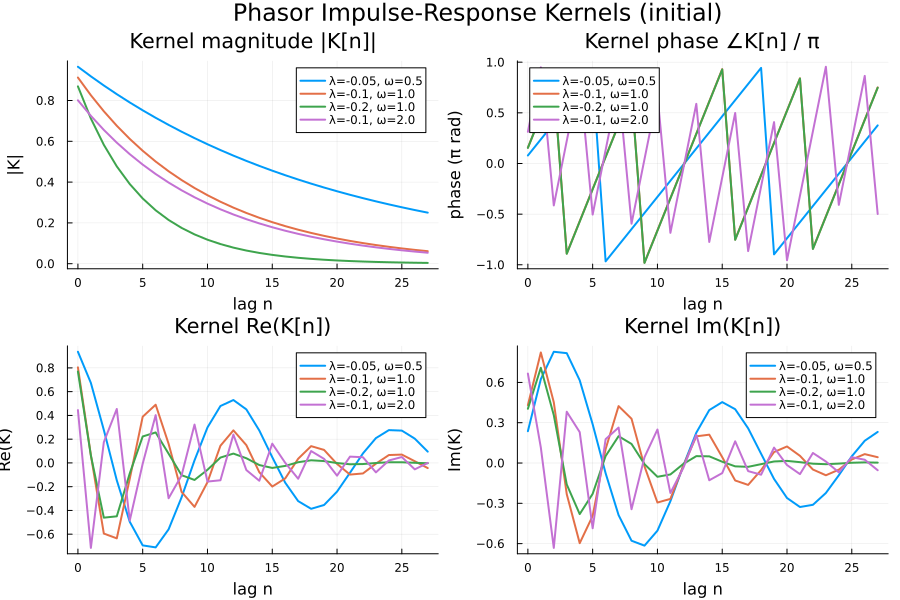

In [2]:
# Show kernels for a few representative oscillators
L_viz = 28
λ_viz = Float32[-0.05, -0.1, -0.2, -0.1]
ω_viz = Float32[0.5, 1.0, 1.0, 2.0]
K_viz = phasor_kernel(λ_viz, ω_viz, 1f0, L_viz)  # 4 × 28

labels = ["λ=-0.05, ω=0.5" "λ=-0.1, ω=1.0" "λ=-0.2, ω=1.0" "λ=-0.1, ω=2.0"]
ts = 0:L_viz-1

p1 = plot(ts, abs.(K_viz)', title="Kernel magnitude |K[n]|",
          xlabel="lag n", ylabel="|K|", label=labels, lw=2,
          legend=:topright)

p2 = plot(ts, angle.(K_viz)' ./ π, title="Kernel phase ∠K[n] / π",
          xlabel="lag n", ylabel="phase (π rad)", label=labels, lw=2,
          legend=:topleft)

p3 = plot(ts, real.(K_viz)', title="Kernel Re(K[n])",
          xlabel="lag n", ylabel="Re(K)", label=labels, lw=2)

p4 = plot(ts, imag.(K_viz)', title="Kernel Im(K[n])",
          xlabel="lag n", ylabel="Im(K)", label=labels, lw=2)

plot(p1, p2, p3, p4; layout=(2, 2), size=(900, 600),
     plot_title="Phasor Impulse-Response Kernels (initial)")

## 5. Model, Loss, and Data

The model is a `Chain` of `PhasorSTFT` → `SSMSelfAttention` → `PhasorDense` → `SSMReadout`.
The first layer uses trainable per-channel frequencies to decompose the input
(like a learnable STFT), re-encoding at a uniform carrier. Downstream layers
operate at synchronized frequencies so relative phases carry meaning.

Following the S5-RF strategy, SSM dynamics parameters (`log_neg_lambda`, `omega`)
use a lower learning rate than connection weights, preventing kernel collapse
without explicit regularization.

In [3]:
function create_model(; D_hidden=128, n_classes=10, C_in=28)
    model = Chain(
        PhasorSTFT(C_in => D_hidden, normalize_to_unit_circle),
        SSMSelfAttention(D_hidden => D_hidden, normalize_to_unit_circle),
        PhasorDense(D_hidden => D_hidden, identity; use_bias=false),
        SSMReadout(D_hidden => n_classes),
    )
    return model
end

function ssm_loss(x, y, model, ps, st)
    x_enc = psk_encode(x)
    sims, _ = model(x_enc, ps, st)
    return mean(similarity_loss(sims, y))
end

function evaluate(model, ps, st, loader, device)
    correct = 0; total = 0
    for (x, y) in loader
        x_dev = x |> device
        y_dev = y |> device
        x_enc = psk_encode(x_dev)
        sims, _ = model(x_enc, ps, st)
        correct += sum(argmax(sims; dims=1) .== argmax(y_dev; dims=1))
        total += size(x, 3)
    end
    return correct / total
end

evaluate (generic function with 1 method)

In [4]:
seed = 42
D_hidden = 128
n_epochs = 20
batchsize = 128
lr = 3e-4
lr_ssm = 1e-4  # SSM dynamics (log_neg_lambda) learn at lower rate than weights

0.0001

In [5]:
rng = Xoshiro(seed)

println("Loading FashionMNIST...")
train_data = FashionMNIST(split=:train)
test_data  = FashionMNIST(split=:test)

x_train = Float32.(train_data.features)
y_train = Float32.(onehotbatch(train_data.targets, 0:9))
x_test  = Float32.(test_data.features)
y_test  = Float32.(onehotbatch(test_data.targets, 0:9))

train_loader = DataLoader((x_train, y_train); batchsize, shuffle=true)
test_loader  = DataLoader((x_test,  y_test);  batchsize)

println("Building model (D_hidden=$D_hidden)...")
model = create_model(; D_hidden, n_classes=10, C_in=28)
ps, st = Lux.setup(rng, model)

_count(nt::NamedTuple) = isempty(nt) ? 0 : sum(_count(v) for v in values(nt))
_count(x::AbstractArray) = length(x)
_count(_) = 0
println("  Trainable parameters: $(_count(ps))")

use_cuda = CUDA.functional()
device = use_cuda ? gpu_device() : cpu_device()
ps = ps |> device
st = st |> device
println("  Device: $(use_cuda ? "CUDA GPU" : "CPU")")

Loading FashionMNIST...
Building model (D_hidden=128)...
  Trainable parameters: 69505
  Device: CUDA GPU


## 6. Similarity Through Time

To visualize how the SSM network discriminates between classes, we compute
codebook similarity at **every timestep** (not just the readout window).

For each sample, we forward through the two SSM layers, extract phase angles
at each timestep, and compute cosine similarity against every codebook prototype.
The **red line** shows similarity to the true class; gray lines show all others.

In [17]:
"""
Compute per-class similarity at every timestep.
Forwards through all layers except the readout (last layer), then computes
codebook similarity at each time step.
Returns (n_classes × L × B) Float32 array.
"""
function similarity_through_time(model, ps, st, x_enc)
    # Forward through all layers except readout (last layer)
    n = length(model.layers)
    z = x_enc
    for i in 1:(n-1)
        sym = Symbol("layer_$i")
        z, _ = model.layers[i](z, getproperty(ps, sym), getproperty(st, sym))
    end

    C, L, B = size(z)
    z_norm = normalize_to_unit_circle(z)
    phases = complex_to_angle(z_norm)          # C × L × B (Phase)

    readout_st = getproperty(st, Symbol("layer_$n"))
    codes = readout_st.codes                   # C × n_classes (Phase)
    n_cls = size(codes, 2)

    # Cosine similarity at each timestep
    p = reshape(phases, C, 1, L, B)            # C × 1 × L × B
    c = reshape(codes, C, n_cls, 1, 1)         # C × n_classes × 1 × 1
    cos_diff = cos.(Float32(π) .* (p .- c))    # C × n_classes × L × B
    sims = mean(cos_diff; dims=1)              # 1 × n_classes × L × B
    return dropdims(sims; dims=1)              # n_classes × L × B
end

class_labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

function plot_similarity_grid(sims, y_samples, title_str)
    plots = []
    for (i, cls) in enumerate(y_samples)
        p = plot(title=class_labels[cls+1], xlabel="time step", ylabel="similarity",
                 legend=false)
        for c in 1:10
            c == cls + 1 && continue
            plot!(p, 1:size(sims, 2), sims[c, :, i], color=:gray, alpha=0.25, lw=0.8)
        end
        plot!(p, 1:size(sims, 2), sims[cls+1, :, i], color=:red, lw=2.5)
        push!(plots, p)
    end
    plot(plots...; layout=(2, 3), size=(1100, 550), plot_title=title_str)
end

plot_similarity_grid (generic function with 1 method)

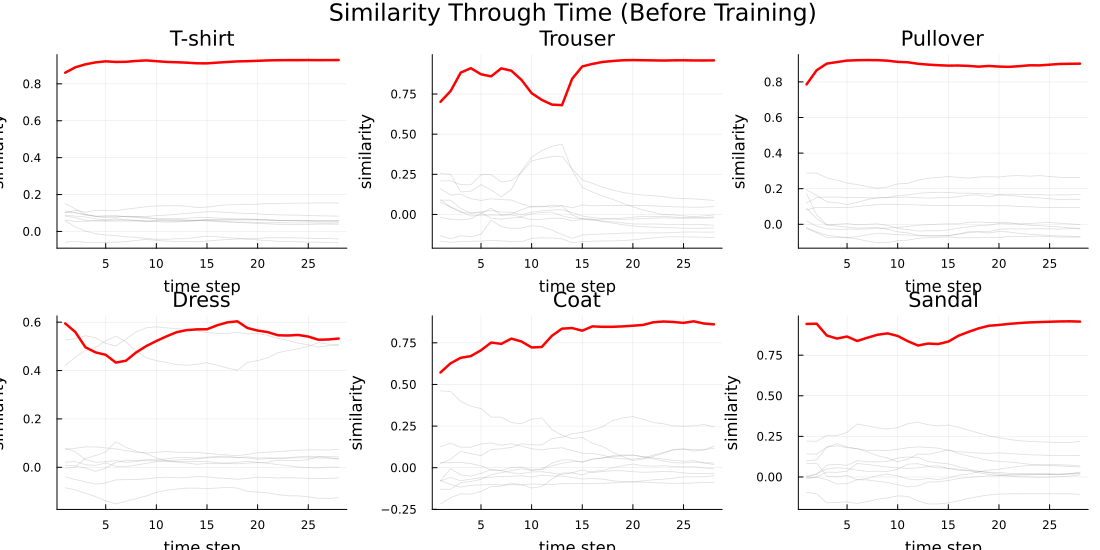

In [18]:
# Pick one sample from each of 6 classes for visualization
sample_indices = [findfirst(==(c), train_data.targets) for c in 0:5]
x_samples = x_train[:, :, sample_indices] |> device
y_samples = train_data.targets[sample_indices]

# Compute similarity at every timestep with initial (untrained) parameters
x_enc_samples = psk_encode(x_samples)
sims_pre = similarity_through_time(model, ps, st, x_enc_samples) |> cpu_device()

fig = plot_similarity_grid(sims_pre, y_samples,
    "Similarity Through Time (Before Training)")

## 7. Training

Uses the package's `train()` function with `similarity_loss` and the SSMReadout's
built-in codebook for classification.

Following the S5-RF strategy, SSM dynamics parameters (`log_neg_lambda`) use a
lower learning rate than connection weights. This prevents the kernels from
collapsing to near-zero decay without needing explicit regularization — the
optimizer can freely adjust weights while the dynamics shift slowly.

In [8]:
args = Args(epochs=1, batchsize=batchsize, lr=lr, lr_ssm=lr_ssm, use_cuda=use_cuda)
all_losses = Float64[]
epoch_accs = Float64[]

for epoch in 1:n_epochs
    losses, ps, st = train(model, ps, st, train_loader, ssm_loss, args)
    append!(all_losses, losses)
    acc = evaluate(model, ps, st, test_loader, device)
    push!(epoch_accs, acc)
    println("Epoch $epoch/$n_epochs  avg_loss=$(round(mean(losses); digits=4))  test_acc=$(round(acc; digits=4))")
end

┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1582


Epoch 1/20  avg_loss=0.5557  test_acc=0.566


┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1582


Epoch 2/20  avg_loss=0.3051  test_acc=0.6922


┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1582


...

Epoch 18/20  avg_loss=0.0967  test_acc=0.8346


┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1582


Epoch 19/20  avg_loss=0.0947  test_acc=0.8357


┌ Info: Training on CUDA GPU
└ @ PhasorNetworks /home/wilkie/code/PhasorNetworks.jl/src/network.jl:1582


Epoch 20/20  avg_loss=0.0932  test_acc=0.8387


## 8. Training Results

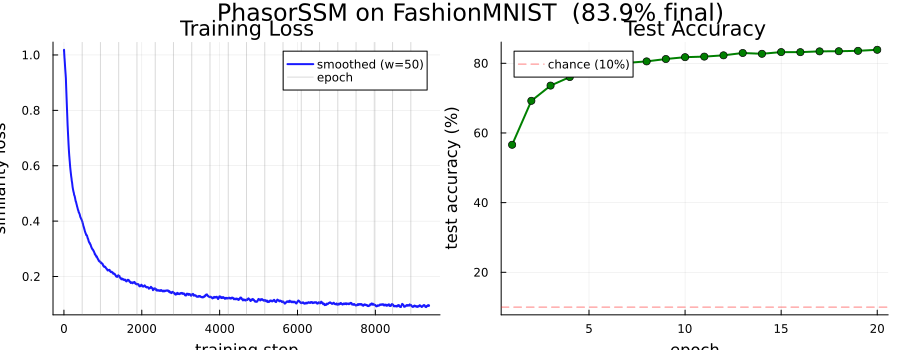

In [12]:
steps_per_epoch = length(all_losses) ÷ n_epochs

# Smooth loss with a running average
window = min(50, steps_per_epoch)
smoothed = [mean(all_losses[max(1,i-window+1):i]) for i in 1:length(all_losses)]

p_loss = plot(smoothed, xlabel="training step", ylabel="similarity loss",
              title="Training Loss", label="smoothed (w=$window)",
              lw=2, color=:blue, alpha=0.9)
# Add epoch boundaries
for e in 1:n_epochs-1
    vline!([e * steps_per_epoch], color=:gray, alpha=0.3, label=(e==1 ? "epoch" : nothing))
end

p_acc = plot(1:n_epochs, epoch_accs .* 100,
             xlabel="epoch", ylabel="test accuracy (%)",
             title="Test Accuracy", label=nothing,
             lw=2, marker=:circle, color=:green)
hline!([100/10], color=:red, ls=:dash, alpha=0.5, label="chance (10%)")

fig = plot(p_loss, p_acc; layout=(1, 2), size=(900, 350),
     plot_title="PhasorSSM on FashionMNIST  ($(round(epoch_accs[end]*100; digits=1))% final)")

In [ ]:
png(fig, "../mnist_training.png")

## 9. Similarity Through Time (After Training)

After training, the SSM layers have learned to produce phase patterns that align
with the codebook prototypes for the correct class. The true class (red) should
now stand out from the other classes (gray) at each timestep.

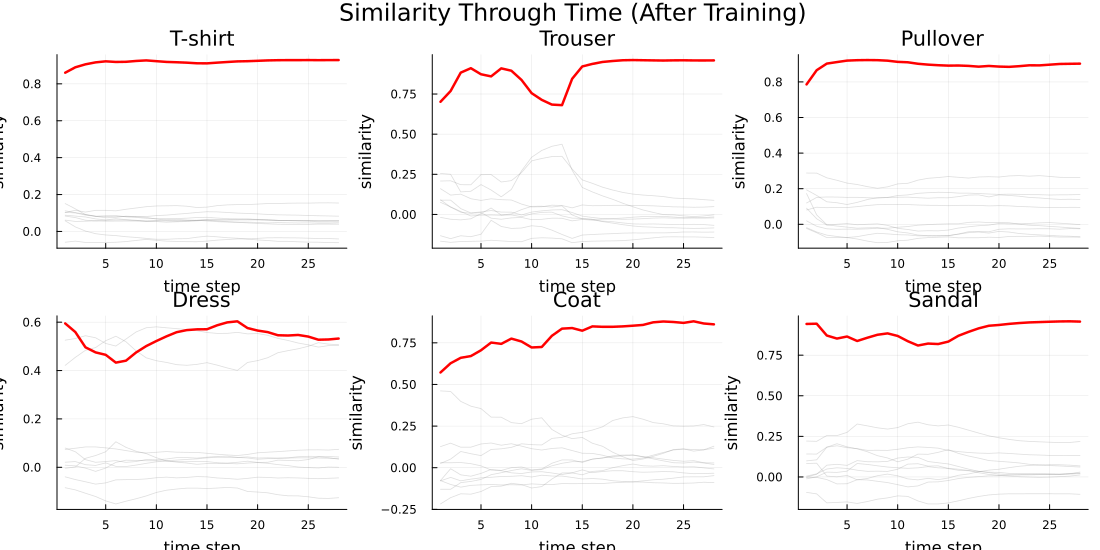

In [13]:
# Compute similarity at every timestep with trained parameters
sims_post = similarity_through_time(model, ps, st, psk_encode(x_samples)) |> cpu_device()

fig = plot_similarity_grid(sims_post, y_samples,
    "Similarity Through Time (After Training)")

In [15]:
png(fig, "../post_train_similarity.png")

"../post_train_similarity.png"

## 10. Learned Kernels

After training, the PhasorSTFT layer's `(λ, ω)` parameters have been adjusted
by gradient descent, learning which frequencies and timescales are informative.
The downstream PhasorDense layer's `λ` also adapts while `ω` remains fixed.

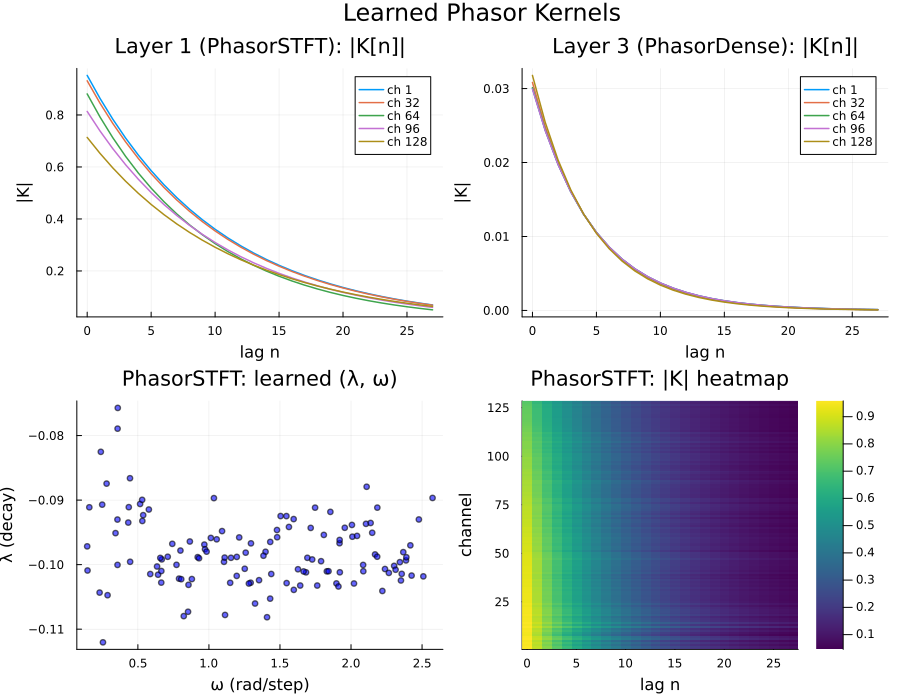

In [11]:
# Extract learned parameters from CPU
ps_cpu = ps |> cpu_device()
st_cpu = st |> cpu_device()

# Layer 1: PhasorSTFT — omega is a trained parameter
λ_l1 = -exp.(ps_cpu.layer_1.log_neg_lambda)
ω_l1 = ps_cpu.layer_1.omega
# Layer 3: PhasorDense — omega is fixed in state
λ_l3 = -exp.(ps_cpu.layer_3.log_neg_lambda)
ω_l3 = st_cpu.layer_3.omega

K_l1 = phasor_kernel(λ_l1, ω_l1, 1f0, 28)
K_l3 = phasor_kernel(λ_l3, ω_l3, 1f0, 28)

# Select a few channels to visualize
ch_show = [1, 32, 64, 96, 128]
ts = 0:27

p_mag1 = plot(title="Layer 1 (PhasorSTFT): |K[n]|", xlabel="lag n", ylabel="|K|")
p_mag3 = plot(title="Layer 3 (PhasorDense): |K[n]|", xlabel="lag n", ylabel="|K|")
for c in ch_show
    plot!(p_mag1, ts, abs.(K_l1[c, :]), label="ch $c", lw=1.5)
    plot!(p_mag3, ts, abs.(K_l3[c, :]), label="ch $c", lw=1.5)
end

# PhasorSTFT: learned frequency distribution
p_params = scatter(ω_l1, λ_l1, xlabel="ω (rad/step)", ylabel="λ (decay)",
                   title="PhasorSTFT: learned (λ, ω)",
                   label=nothing, marker=:circle, ms=3, alpha=0.6, color=:blue)

# Heatmap of kernel magnitude for PhasorSTFT layer
p_heat = heatmap(0:27, 1:D_hidden, abs.(K_l1),
                 xlabel="lag n", ylabel="channel",
                 title="PhasorSTFT: |K| heatmap", color=:viridis)

plot(p_mag1, p_mag3, p_params, p_heat;
     layout=(2, 2), size=(900, 700),
     plot_title="Learned Phasor Kernels")

## Summary

The discrete SSM approach replaces the continuous ODE solver with a precomputed
convolution kernel, giving **identical dynamics** but with parallel computation.

**PhasorSTFT — trainable frequency decomposition**: The first layer acts as a
learnable STFT. Each channel is a multi-compartment neuron with trainable `(λ, ω)`:
a signal compartment integrates weighted input while a reference compartment
(analytically known) provides the carrier. The invariant phase difference —
what the input contributed at frequency `ω_f` — is re-encoded at the downstream
carrier `ω_out` via frequency-shift modulation. This preserves the physical
interpretation of coupled oscillators while allowing each channel to tune to
informative input frequencies.

**PhasorDense — synchronized downstream layers**: After PhasorSTFT re-encodes
at a uniform carrier, subsequent PhasorDense layers operate with all channels
at the same `ω`. This ensures relative phases between neurons remain constant
through time, consistent with the HD/VSA requirement for a synchronized phase
vector.

**Self-attention**: The `SSMSelfAttention` layer between the STFT and downstream
stages enables dynamic content-based routing via phasor phase similarity.

**Similarity-based readout**: The `SSMReadout` layer computes codebook similarity
at every timestep before averaging, avoiding phase-cancellation.

**Key observations:**
- The PhasorSTFT layer learns to spread its frequencies across the informative
  range, with decay rates adapting to match the temporal structure of the data.
- Downstream synchronized layers maintain coherent phase vectors, enabling
  similarity-based classification.
- The S5-RF differential learning rate strategy (lower `lr_ssm` for dynamics
  parameters) prevents kernel collapse without explicit regularization.